In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

WSD = '/content/drive/My Drive/Colab Notebooks/debluring/avito'

import sys
sys.path.append(WSD)

Mounted at /content/drive


In [ ]:
!pip install torch torchvision
!pip install tqdm requests scikit-image matplotlib albumentations
!pip install segmentation_models_pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
!pip install segmentation_models_pytorch

In [ ]:
# загрузим изображение через URL
import requests
from PIL import Image
import numpy as np
from io import BytesIO

def download_image(url):
    """
    Скачивает изображение по URL, сохраняет его в формате RGB и возвращает массив NumPy.

    :param url: URL изображения
    :return: Массив NumPy изображения в формате RGB
    """
    try:
        # Скачиваем изображение
        response = requests.get(url)
        response.raise_for_status()  # Проверяем, что запрос успешен

        # Открываем изображение из байтового потока
        image = Image.open(BytesIO(response.content)).convert('RGB')

        # Преобразуем изображение в массив NumPy
        image_array = np.array(image)

        return image_array
    except Exception as e:
        print(f"Ошибка при скачивании или обработке изображения: {e}")
        return None


In [ ]:
image = download_image("http://labelimages.avito.ru/14221834484.jpg")

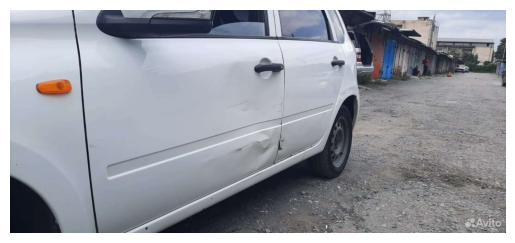

In [ ]:
# посмотрим на него

import matplotlib.pyplot as plt

def show_image(image_array):
    """
    Отображает изображение из массива NumPy.

    :param image_array: Массив NumPy изображения в формате RGB
    """
    try:
        if image_array is None:
            print("Передан пустой массив изображения.")
            return

        # Отображаем изображение
        plt.imshow(image_array)
        plt.axis('off')  # Убираем оси для чистоты отображения
        plt.show()
    except Exception as e:
        print(f"Ошибка при отображении изображения: {e}")

# Пример использования
if image is not None:
    show_image(image)

In [ ]:
# подгоним по размерам, чтобы скормить нашей модели

import cv2

def resize_and_pad(image):
        h, w = image.shape[:2]
        max_size = 512

        # Вычисляем новые размеры с сохранением пропорций
        if h > w:
            new_h = max_size
            new_w = int(w * max_size / h)
        else:
            new_w = max_size
            new_h = int(h * max_size / w)

        # Изменяем размер
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)

        # Создаем новые изображения с черным фоном
        padded_image = np.zeros((max_size, max_size, 3), dtype=image.dtype)

        # Вычисляем позиции для вставки
        top = (max_size - new_h) // 2
        left = (max_size - new_w) // 2

        # Вставляем изображения в центр
        padded_image[top:top+new_h, left:left+new_w] = image

        return padded_image

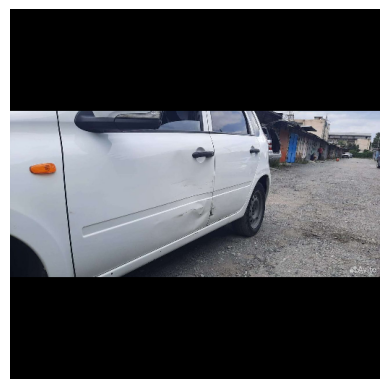

In [ ]:
image = resize_and_pad(image)
assert image.shape == (512, 512, 3)
show_image(image)

In [ ]:
# загрузка моделей
import segmentation_models_pytorch as smp
import torch

import torchvision
from torchvision.utils import make_grid

from tqdm import tqdm

import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"GPU: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device: ", device)

def get_damage_model(model_path):
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",    # !!!!!!!!
        in_channels=3,
        classes=9,
        activation=None,
        decoder_channels=(256, 128, 64, 32, 16)
    )

    torch.manual_seed(11)
    model = model.to(device)
    # model_path = os.path.join(WSD, './checkpoints/baseline/epoch_101.pth')
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device))['model_state_dict'])

    return model.eval()

def get_parts_model(model_path):
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",    # !!!!!!!!
        in_channels=3,
        classes=13,
        activation=None,
        decoder_channels=(256, 128, 64, 32, 16)
    )

    torch.manual_seed(11)
    model = model.to(device)
    # model_path = os.path.join(WSD, './checkpoints/baseline/epoch_101.pth')
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device))['model_state_dict'])

    return model.eval()

damage_model_path = os.path.join(WSD, './checkpoints/baseline/epoch_196.pth')
parts_model_path = os.path.join(WSD, './checkpoints/parts/epoch_196.pth')

damage_model = get_damage_model(damage_model_path)
parts_model = get_parts_model(parts_model_path)

GPU: True
device:  cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [92]:
def get_damage_score(damage_model, parts_model, image):

    def prepare_image(image):
        car_image = image.astype(np.float32)/255.0
        return torch.from_numpy(car_image).permute(2, 0, 1).float()

    image_tensor = prepare_image(image)[None, ...].to(device)

    damage_maps = F.softmax(damage_model(image_tensor), dim=1)[0]
    parts_maps = F.softmax(parts_model(image_tensor), dim=1)[0]

    total_car_square = np.ones_like(parts_maps[2, ...].detach().numpy()) - parts_maps[2, ...].detach().numpy()
    total_car_square = total_car_square.sum()

    total_damage_square = np.ones_like(damage_maps[4, ...].detach().numpy()) - damage_maps[4, ...].detach().numpy()
    total_damage_square = total_damage_square.sum()

    return total_damage_square / total_car_square



In [73]:
# с помощью моделей построим оценку повреждений по отдельным частям
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_damage_part_matrix(damage_model, parts_model, image):

    def prepare_image(image):
        car_image = image.astype(np.float32)/255.0
        return torch.from_numpy(car_image).permute(2, 0, 1).float()

    image_tensor = prepare_image(image)[None, ...].to(device)

    damage_maps = F.softmax(damage_model(image_tensor), dim=1)[0]
    parts_maps = F.softmax(parts_model(image_tensor), dim=1)[0]

    # Извлекаем размеры
    num_damage_maps, H, W = damage_maps.shape
    num_parts_maps, _, _ = parts_maps.shape

    # Инициализируем матрицу результата
    result_matrix = torch.zeros((num_damage_maps, num_parts_maps))

    # Вычисляем значения для каждой ячейки матрицы
    for x in range(num_damage_maps):
        for y in range(num_parts_maps):
            T_damage = 0.0001
            T_parts = 0.0001

            # Извлекаем карты признаков X и Y
            damage_map = damage_maps[x, :, :]  # (H, W)
            parts_map = parts_maps[y, :, :]    # (H, W)

            # damage_map_binary = (damage_map >= T_damage).float()  # Бинаризация damage_map
            # parts_map_binary = (parts_map >= T_parts).float()    # Бинаризация parts_map

            # Поэлементное произведение бинаризованных карт
            # product = damage_map_binary * parts_map_binary  # (H, W)
            product = damage_map * parts_map

            # Сумма произведения
            numerator = product.sum()  # Скаляр

            # Сумма бинаризованной карты parts_map
            denominator = parts_map.sum()  # Скаляр

            # Вычисляем значение для ячейки (X, Y)
            result_matrix[x, y] = numerator / denominator if denominator != 0 else 0.0

    return result_matrix

In [93]:
damage_part_matrix = get_damage_score(damage_model, parts_model, image)
damage_part_matrix

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [85]:
# а теперь все вместе

def get_damage_laval(image_url):
    damage_weights = [[6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
                      [4, 3, 0, 2, 0, 2, 2, 1, 4, 4, 4, 5, 4],
                      [1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 1, 3, 1],
                      [2, 3, 0, 2, 1, 2, 2, 1, 2, 2, 2, 3, 3],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
                      [2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
                      [1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                      [1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

    damage_weights = np.array(damage_weights)

    image = download_image(image_url)

    show_image(image)

    damage_part_matrix = get_damage_part_matrix(damage_model, parts_model, image).detach().numpy()

    laval = damage_part_matrix * damage_weights

    return laval.sum().item()

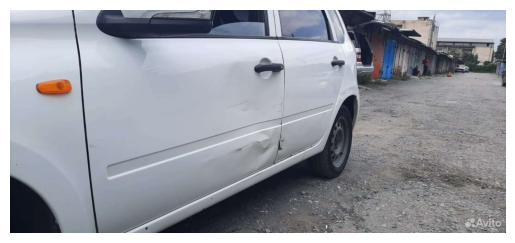

1.0971782663701788

In [86]:
url = "http://labelimages.avito.ru/14221834484.jpg"
get_damage_laval(url)

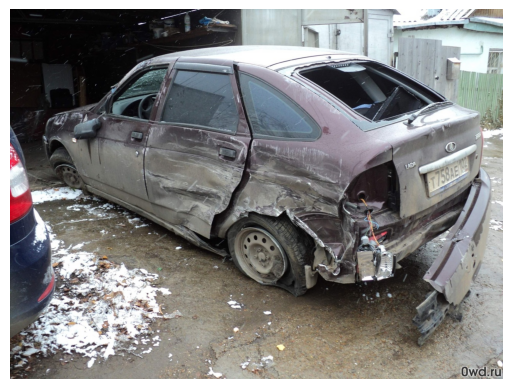

2.3458275086040885

In [87]:
url = "https://sun9-49.userapi.com/impg/hyV6t86TP54RCgIyC1i3iw7Y-5932du7lKZmlA/NL1ltIP87Ng.jpg?size=1280x960&quality=95&sign=9997e044f2a68e15803e9078517b6867&c_uniq_tag=61K83DjtfF8zTLwGZVBw5htFRB3Xszln5nJ1Yl1vLzE&type=album"
get_damage_laval(url)

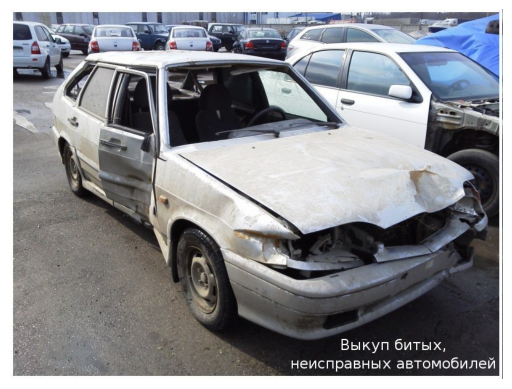

2.737745984473463

In [88]:
url = "https://sun9-43.userapi.com/impf/c848416/v848416033/37d45/2zAUWvCf-wY.jpg?size=800x600&quality=96&sign=c2a8c1352f77bacedc7f4753336c12a6&c_uniq_tag=sKKNO1iuo0JJ3Lbgus1NlYkyhxXEFpQUhI3-qlaUIu4&type=album"



get_damage_laval(url)

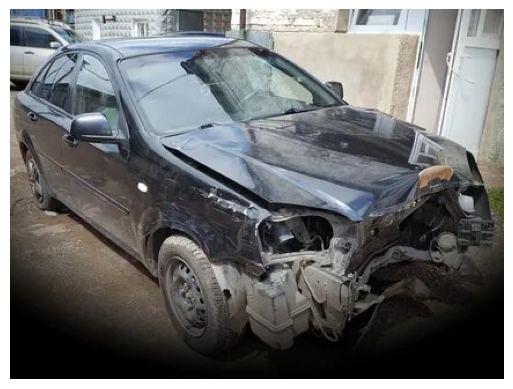

0.01732445216377243

In [89]:
url = "https://avatars.mds.yandex.net/i?id=19b4992b561f705756989e5deada1f4bb73d5d5f-10754966-images-thumbs&n=13"
get_damage_laval(url)

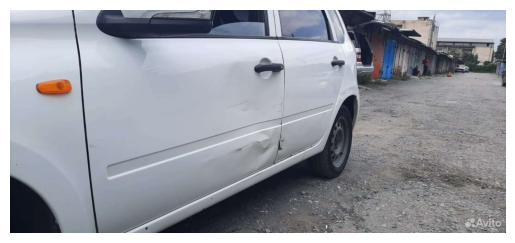

<ipython-input-55-b9dd6e26804c>:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  laval = damage_part_matrix * damage_weights


33

In [60]:
url = "http://labelimages.avito.ru/14221834484.jpg"
get_damage_laval(url)

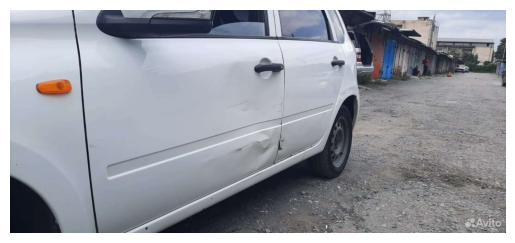

<ipython-input-55-b9dd6e26804c>:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  laval = damage_part_matrix * damage_weights


33

In [61]:
url = "http://labelimages.avito.ru/14221834484.jpg"
get_damage_laval(url)

In [ ]:
url = "http://labelimages.avito.ru/14221834484.jpg"
get_damage_laval(url)

In [ ]:
url = "http://labelimages.avito.ru/14221834484.jpg"
get_damage_laval(url)